In [1]:
import numpy as np
import pickle
import importlib
from scipy.spatial import ConvexHull
# from scipy.stats import gaussian_kde
from scipy.stats import multivariate_normal, chi2
from scipy.interpolate import splprep, splev
import matplotlib.pyplot as plt
from adjustText import adjust_text
# import seaborn as sns
# --
import utils
importlib.reload(utils)
from utils import get_sorted_anchor_coordinates_np, get_sorted_anchor_coordinates
# --

In [2]:
def calc_z_min(microstate_index, anchor_coordinates):
    cur_z = anchor_coordinates[microstate_index][2]
    for i in range(microstate_index - 1, -1, -1):
        if anchor_coordinates[i][2] < cur_z:
            return ((anchor_coordinates[i][2] + cur_z) / 2) - 5
        

def calc_z_max(microstate_index, anchor_coordinates):
    cur_z = anchor_coordinates[microstate_index][2]
    for i in range(microstate_index + 1, 215):
        if anchor_coordinates[i][2] > cur_z:
            return ((anchor_coordinates[i][2] + cur_z) / 2) + 5

def microstate_index_to_coordinate_edges(microstate_index: int, anchor_coordinates: np.array) -> np.array:
    """
    return (z_min, z_max, rmin, rmax, phi_min, phi_max)
    """
    if microstate_index < 0 or microstate_index >= 218:
        raise ValueError("Microstate index must be between 0 and 217 inclusive.")
    
    # nuc and cyt
    if microstate_index == 0:
        return np.array([-30, -20, 0, 20, 0, 2*np.pi])
    if microstate_index == 217:
        return np.array([25, 35, 0, 20, 0, 2*np.pi])
    
    microstate_index -= 1  # Adjust index for fgs
    
    if microstate_index in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]:
        # bottom fgs 
        z_min = -20
        z_max = calc_z_max(microstate_index, anchor_coordinates)
    elif microstate_index in [208, 209, 210, 211, 212, 213, 214, 215]:
        # top fgs 
        z_min = calc_z_min(microstate_index, anchor_coordinates)
        z_max = 25
    else: 
        # other fgs
        z_min = calc_z_min(microstate_index, anchor_coordinates)
        z_max = calc_z_max(microstate_index, anchor_coordinates)
    
    anchor_x = anchor_coordinates[microstate_index][0]
    anchor_y = anchor_coordinates[microstate_index][1]
    rmin = 0
    rmax = np.sqrt(anchor_x**2 + anchor_y**2)

    index_mod_8 = microstate_index % 8
    phi_min = (index_mod_8 * np.pi / 4)
    phi_max = phi_min + (np.pi / 4)
    
    return np.array([z_min, z_max, rmin, rmax, phi_min, phi_max])
    
    
def calc_coordinate_edges_dict(anchor_coordinates):
    """
    Calculate the coordinate edge dictionary for all microstates.
    Returns a dictionary where keys are microstate indices and values are coordinate edges.
    """
    coordinate_edges = {}
    for i in range(218):
        coordinate_edges[i] = microstate_index_to_coordinate_edges(i, anchor_coordinates)
    
    return coordinate_edges


def sample_from_cluster(cluster: np.array, n_samples: int, coordinate_edges) -> np.array:
    """
    cluster - makeup of the cluster, i.e. probabilities of each microstate (nuc/fgs/cyt) - size (218)
    n_samples - number of samples to draw from the cluster
    returns a sample of size n_samples from the cluster, but in spatial space
    """
    # Normalize the cluster to ensure it sums to 1
    cluster = cluster / np.sum(cluster)
    # Draw samples from the multinomial distribution
    sample = np.random.multinomial(n=n_samples, pvals=cluster) # size (218,)
    # Convert sample indices to spatial coordinates
    spatial_coordinates = np.zeros((n_samples, 3))  # Initialize spatial coordinates array
    idx = 0  # Running index to track position in spatial_coordinates array

    for microstate_index, count in enumerate(sample):
        if count > 0:
            edges = coordinate_edges[microstate_index]
            z_min, z_max, rmin, rmax, phi_min, phi_max = edges
            
            # Sample uniformly within the defined edges
            z_samples = np.random.uniform(z_min, z_max, count)
            phi_samples = np.random.uniform(phi_min, phi_max, count)
            # Sample r with uniform density (proportional to area)
            # Use inverse transform sampling: r = sqrt(u*(rmax^2 - rmin^2) + rmin^2)
            u = np.random.uniform(0, 1, count)
            r_samples = np.sqrt(u * (rmax**2 - rmin**2) + rmin**2)
            
            
            # Convert polar coordinates to Cartesian coordinates
            x_samples = r_samples * np.cos(phi_samples)
            y_samples = r_samples * np.sin(phi_samples)
            
            # Fill the spatial coordinates for this microstate
            spatial_coordinates[idx:idx+count] = np.column_stack((x_samples, y_samples, z_samples))
            
            # Update the index
            idx += count  
    return spatial_coordinates
    
def calc_smooth_convex_hull(scatter, smoothing_factor=0.1, num_points=100):
    """
    Calculate the convex hull of the scatter points and smooth it using spline interpolation.
    Returns the vertices of the smooth convex hull.
    
    Parameters:
    - scatter: array of points
    - smoothing_factor: controls smoothness (0 = interpolation, higher = more smoothing)
    - num_points: number of points in the final smooth curve
    """
    # Calculate the convex hull
    hull = ConvexHull(scatter)
    
    # Extract the vertices of the convex hull
    vertices = scatter[hull.vertices]
    
    # Close the hull by adding the first vertex at the end for periodicity
    closed_vertices = np.vstack([vertices, vertices[0]])
    
    # Parametric spline interpolation for smooth curve
    # s parameter controls smoothing: 0 = interpolation, higher = more smoothing
    tck, u = splprep([closed_vertices[:, 0], closed_vertices[:, 1]], 
                     s=smoothing_factor * len(vertices), 
                     per=True)  # per=True for periodic (closed) curve
    
    # Generate smooth curve with more points
    u_new = np.linspace(0, 1, num_points)
    smooth_x, smooth_y = splev(u_new, tck)
    
    # Combine into vertices array
    smoothed_vertices = np.column_stack([smooth_x, smooth_y])
    
    return smoothed_vertices
    


Cluster 1 has too few points (479), skipping.
Cluster 2 has too few points (512), skipping.
Cluster 3 has too few points (525), skipping.
Cluster 4 has too few points (790), skipping.
Cluster 5 has too few points (376), skipping.
Cluster 6 has too few points (222), skipping.
Cluster 7 has too few points (606), skipping.
Cluster 8 has too few points (236), skipping.
Cluster 9 has too few points (775), skipping.
Cluster 10 has too few points (89), skipping.
Cluster 13 has too few points (189), skipping.
Cluster 14 has too few points (226), skipping.
Cluster 16 has too few points (789), skipping.
Cluster 17 has too few points (80), skipping.
Cluster 18 has too few points (106), skipping.
Cluster 19 has too few points (792), skipping.
Cluster 20 has too few points (125), skipping.
Cluster 22 has too few points (627), skipping.
Cluster 23 has too few points (98), skipping.
Cluster 24 has too few points (119), skipping.
Cluster 26 has too few points (346), skipping.
Cluster 28 has too few po

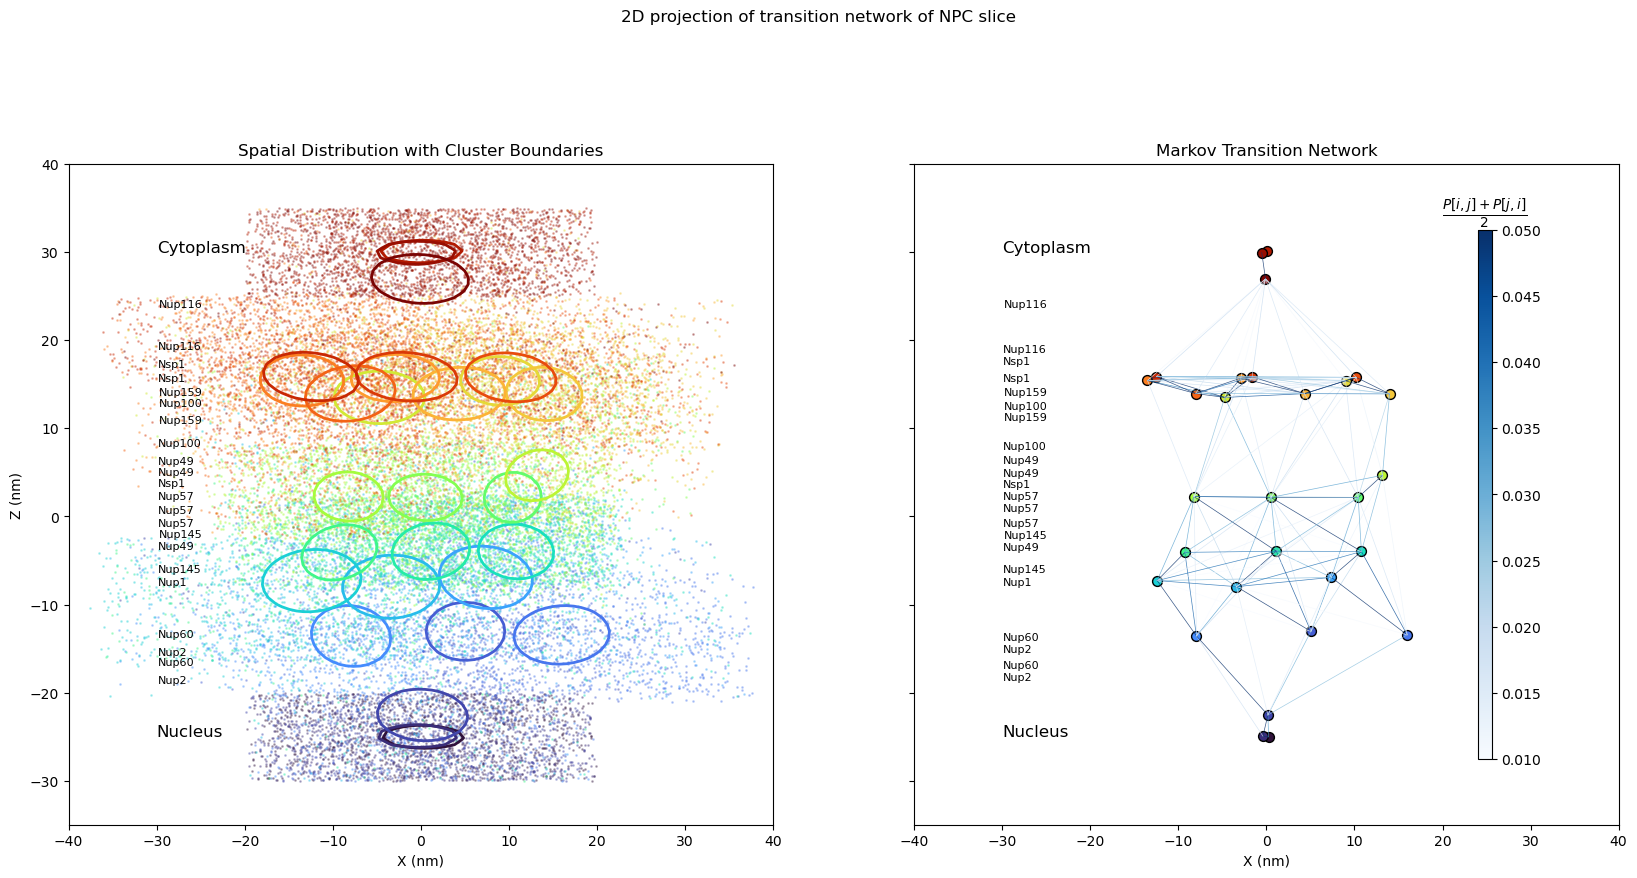

In [56]:

from torch import layout


n_clusters = 80
n_samples = 1000


with open(f"data/clusterings/interactions-150-180-100ns-3k-hist-74pca-kmeans-{n_clusters}clusters.pickle", "rb") as f:
        pca_cluster = pickle.load(f)
clusters = pca_cluster.get_inverse_centers()
clusters[clusters < 0.01] = 0  # Set negative probabilities to zero
anchor_coordinates = get_sorted_anchor_coordinates_np()[1]
coordinate_edges = calc_coordinate_edges_dict(anchor_coordinates)


plt.rcParams['text.usetex'] = False # Use LaTeX for text rendering
fig, (ax1, ax2) = plt.subplots(1, 2,
                               sharey=True)

fig.set_figheight(10)
fig.set_figwidth(20)
fig.suptitle('2D projection of transition network of NPC slice')
# fig = plt.figure(figsize=(20, 10))
# ax1 = fig.add_subplot(211)
# ax2 = fig.add_subplot(221)

ax1.set_xlabel('X (nm)')
ax1.set_ylabel('Z (nm)')
ax1.set_title('Spatial Distribution with Cluster Boundaries')
ax1.set_xlim(-40, 40)
ax1.set_ylim(-35, 40)
ax1.set_aspect('equal', adjustable='box')

ax2.set_xlabel('X (nm)')
ax2.set_title('Markov Transition Network')
ax2.set_xlim(-40, 40)
ax2.set_ylim(-35, 40)
ax2.set_aspect('equal', adjustable='box')


good_cluster_indices = [0, 1, 2]  # Always include the first and last clusters (nuc and cyt)
for i, cluster in enumerate(clusters):
    spatial_coordinates = sample_from_cluster(cluster, n_samples, coordinate_edges)
    
    # remove all points with phi outside [-(1/2)*pi, (1/2)*pi]
    min_phi = -4*np.pi / 8
    max_phi = 4*np.pi / 8
    phi = np.arctan2(spatial_coordinates[:, 1], spatial_coordinates[:, 0])
    spatial_coordinates = spatial_coordinates[(phi >= min_phi) & (phi <= max_phi)]
    if spatial_coordinates.shape[0] < 0.8 * n_samples:
        print(f"Cluster {i+1} has too few points ({spatial_coordinates.shape[0]}), skipping.")
        continue  # Skip empty clusters
    good_cluster_indices.append(i)
    
    
    # # if the angle of 75% of the points is within pi/4 of each other, remove all other points
    # angles = np.arctan2(spatial_coordinates[:, 1], spatial_coordinates[:, 0])
    # angle_mean = np.mean(angles)
    # angle_std = np.std(angles)
    # angle_threshold = np.pi / 4
    # angle_mask = (angles >= angle_mean - angle_threshold) & (angles <= angle_mean + angle_threshold)
    # spatial_coordinates = spatial_coordinates[angle_mask]
    # if spatial_coordinates.shape[0] < 0.8 * n_samples:
    #     print(f"Cluster {i+1} has too few points after angle filtering ({spatial_coordinates.shape[0]}), skipping.")
    #     continue  # Skip empty clusters
good_cluster_indices.append(n_clusters - 1)  # Always include the last cluster (cyt)
good_cluster_indices.append(n_clusters - 2)
good_cluster_indices.append(n_clusters - 3)
    
colors = plt.cm.turbo(np.linspace(0, 1, len(good_cluster_indices)))
mus = []
covs = []
for color_i, cluster_i in enumerate(good_cluster_indices):
    cluster = clusters[cluster_i]
    spatial_coordinates = sample_from_cluster(cluster, n_samples, coordinate_edges)[:, [1, 2]] # keep only the y and z coordinates
    
    # Plot the points
    ax1.scatter(spatial_coordinates[:, 0], spatial_coordinates[:, 1], 
              alpha=0.3, color=colors[color_i], s=1, label=f'Cluster {cluster_i+1}')
    
    # Create convex hull and draw boundary line
    # hull_vertices = calc_smooth_convex_hull(spatial_coordinates)
    # ax.plot(hull_vertices[:, 0], hull_vertices[:, 1], 
    #     color=colors[i], linewidth=2)
    
    # Estimate gaussian that generates the cluster
    mu = np.mean(spatial_coordinates, axis=0)
    mus.append(mu)
    cov = np.cov(spatial_coordinates, rowvar=False)
    covs.append(cov)
    rv = multivariate_normal(mu, cov)
    # plot contour of the gaussian at 95% confidence level
    x_min, x_max = ax1.get_xlim()
    y_min, y_max = ax1.get_ylim()
    x = np.linspace(x_min, x_max, 100)
    y = np.linspace(y_min, y_max, 100)
    X, Y = np.meshgrid(x, y)
    pos = np.dstack((X, Y))
    confidence_level = 0.1
    chi2_val = chi2.ppf(confidence_level, df=2)
    ax1.contour(X, Y, rv.pdf(pos), levels=[np.exp(-chi2_val/2) * rv.pdf(mu)], colors=colors[color_i], linewidths=2)
    ax2.scatter(mu[0], mu[1], color=colors[color_i], s=50, label=f'Cluster {cluster_i+1} Mean', edgecolor='black')


# for pairs of clusters, draw a line between them
with open(f"data/transition_matrices/cluster-kmeans/74pca-{n_clusters}clusters.pickle", "rb") as f:
    P = pickle.load(f)
min_transition_probability = 0.01
max_transition_probability = 0.05
# transitions_vmin, transitions_vmax = np.min(P), np.max(P)
transitions_cmap = plt.cm.Blues 
transitions_norm = plt.Normalize(vmin=min_transition_probability, vmax=max_transition_probability)
for i in range(len(good_cluster_indices) - 1):
    for j in range(i + 1, len(good_cluster_indices)):
        cluster_i = good_cluster_indices[i]
        cluster_j = good_cluster_indices[j]
        prob = (P[cluster_i, cluster_j] + P[cluster_j, cluster_i]) / 2
        if P[cluster_i, cluster_j] > min_transition_probability:  # Only draw lines for significant transitions
            mu_i = mus[i]
            mu_j = mus[j]
            color = transitions_cmap(transitions_norm(prob))
            ax2.plot([mu_i[0], mu_j[0]], [mu_i[1], mu_j[1]], color=color, alpha=0.8, linewidth=0.5)
# Add transition colorbar
sm = plt.cm.ScalarMappable(cmap=transitions_cmap, norm=transitions_norm)
sm.set_array([])
cbar = fig.colorbar(sm, cax=ax2.inset_axes([0.8, 0.1, 0.02, 0.8]))
cbar.ax.set_title(r'$\frac{P[i,j] + P[j,i]}{2}$', fontsize=14)
# cbar.set_label(r'$\frac{P[i,j] + P[j,i]}{2}$', rotation=270, labelpad=20)



# add nup annotations
anchor_coordinates = get_sorted_anchor_coordinates()
anchor_coordinates_np = get_sorted_anchor_coordinates_np()
texts1 = []
texts2 = []
target_ys = []
target_zs = []
for nup, coords in anchor_coordinates.items():
    if nup[-2:] in ['06',  '14', '22']: # ['02', '10', '18']: #+ : 
        x = coords[0]
        y = coords[1]
        z = coords[2] + (-0.1 if nup[3:-3] == '2' else 0.0) 
        phi = 0.0
        # rotate point bu phi on z axis
        y_rotated = x * np.sin(phi) + y * np.cos(phi)
        label = nup[:-3]
        target_ys.append(y_rotated)
        target_zs.append(z)
        texts1.append(ax1.text(-30, z, label, fontsize=8))
        texts2.append(ax2.text(-30, z, label, fontsize=8))
ax1.text(-30, 30, "Cytoplasm", fontsize=12)
ax1.text(-30, -25, "Nucleus", fontsize=12)
ax2.text(-30, 30, "Cytoplasm", fontsize=12)
ax2.text(-30, -25, "Nucleus", fontsize=12)


adjust_text(texts1, ax = ax1, ha='center', only_move={'text': 'y'}, force_pull=(0.5, 0.01))
adjust_text(texts2, ax = ax2, ha='center', only_move={'text': 'y'}, force_pull=(0.5, 0.01))




plt.show()


# ideas:
# if clusters share > 95% of area, merge them
# in 3 spoke view, remove all clusters that have less than 75% points in the 3 spokes
# remove all points outside of the 3 spokes
